<a href="https://colab.research.google.com/github/Pawankumarhr/fake-news-detection/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# prompt: mount  drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn textblob requests feedparser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 2.2 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=4352eb61d77f63aad78c123a086068e0c76fbe1084db61288e09e5b5aa6e69cb
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [12]:
fake_df = pd.read_csv('/content/drive/MyDrive/fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/true.csv')

In [13]:
fake_df['label'] = 0
true_df['label'] = 1

In [14]:
df = pd.concat([fake_df, true_df]).reset_index(drop=True)

# Shuffle the combined dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [15]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  


In [16]:
print("\nDataset Information:")
print(df.info())

print("\nNull Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['label'].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

Null Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label Distribution:
label
0    23481
1    21417
Name: count, dtype: int64


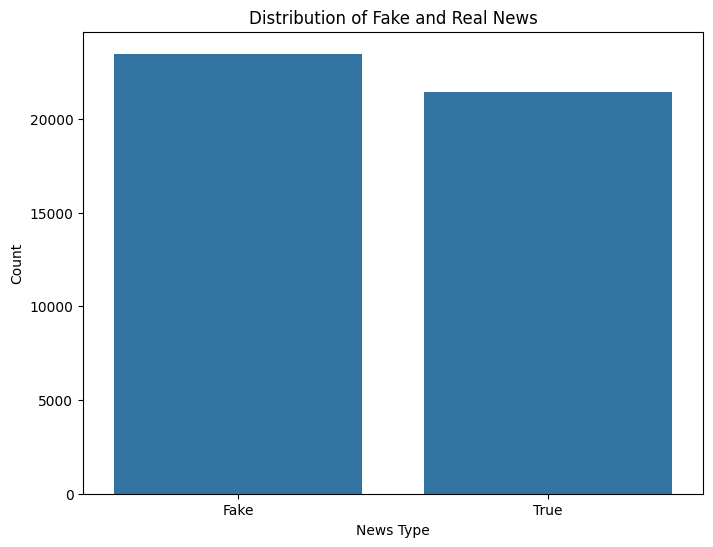

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Fake and Real News')
plt.xticks([0, 1], ['Fake', 'True'])
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

In [18]:
df['text_length'] = df['text'].apply(len)

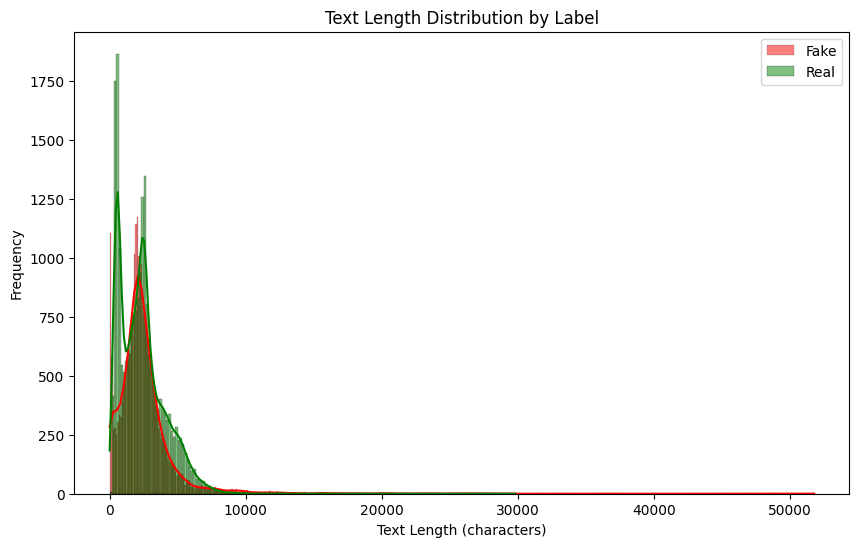

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['label'] == 0]['text_length'], color='red', label='Fake', kde=True, alpha=0.5)
sns.histplot(df[df['label'] == 1]['text_length'], color='green', label='Real', kde=True, alpha=0.5)
plt.legend()
plt.title('Text Length Distribution by Label')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()

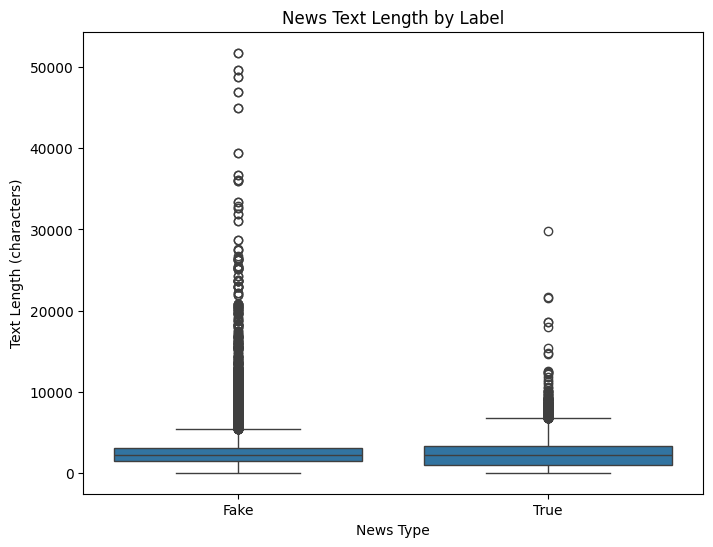

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='text_length', data=df)
plt.title('News Text Length by Label')
plt.xticks([0, 1], ['Fake', 'True'])
plt.xlabel('News Type')
plt.ylabel('Text Length (characters)')
plt.show()

In [21]:
print("\nCalculating sentiment polarity (this may take a few minutes)...")
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)



Calculating sentiment polarity (this may take a few minutes)...


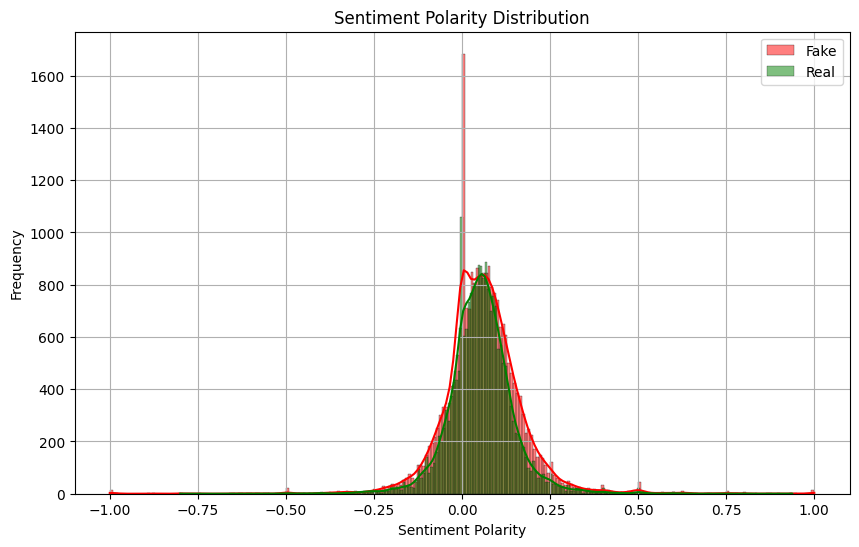

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['label'] == 0]['sentiment'], color='red', label='Fake', kde=True, alpha=0.5)
sns.histplot(df[df['label'] == 1]['sentiment'], color='green', label='Real', kde=True, alpha=0.5)
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
df['content'] = df['title'] + ' ' + df['text']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df['content'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [26]:
print("\nVectorizing text data...")
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


Vectorizing text data...


In [27]:
print("\nTraining the model...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)


Training the model...


LogisticRegression(max_iter=1000, random_state=42)

In [28]:
y_pred = model.predict(X_test_tfidf)

In [29]:
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))


Model Evaluation:
Accuracy: 0.9857461024498887

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4710
        True       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



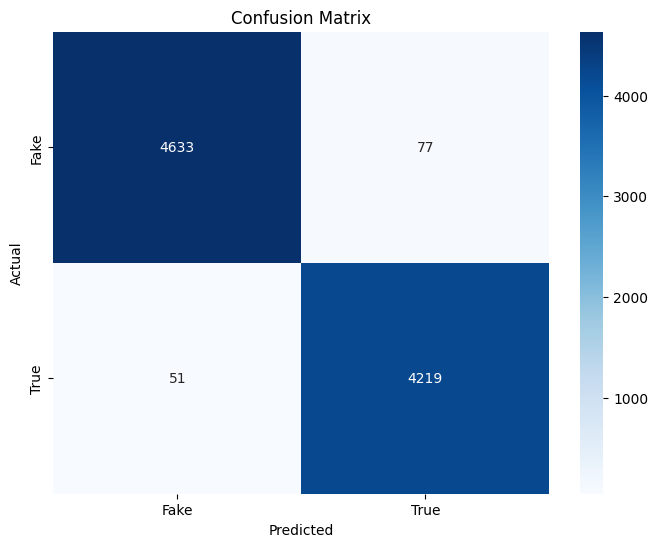

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
if hasattr(model, 'coef_'):
    # Get feature names from TF-IDF
    feature_names = vectorizer.get_feature_names_out()

    # Get coefficients from the model
    coefficients = model.coef_[0]

    # Create a DataFrame for visualization
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })


In [32]:
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

<ipython-input-33-243a86c65d92>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_real_features, palette='Greens')


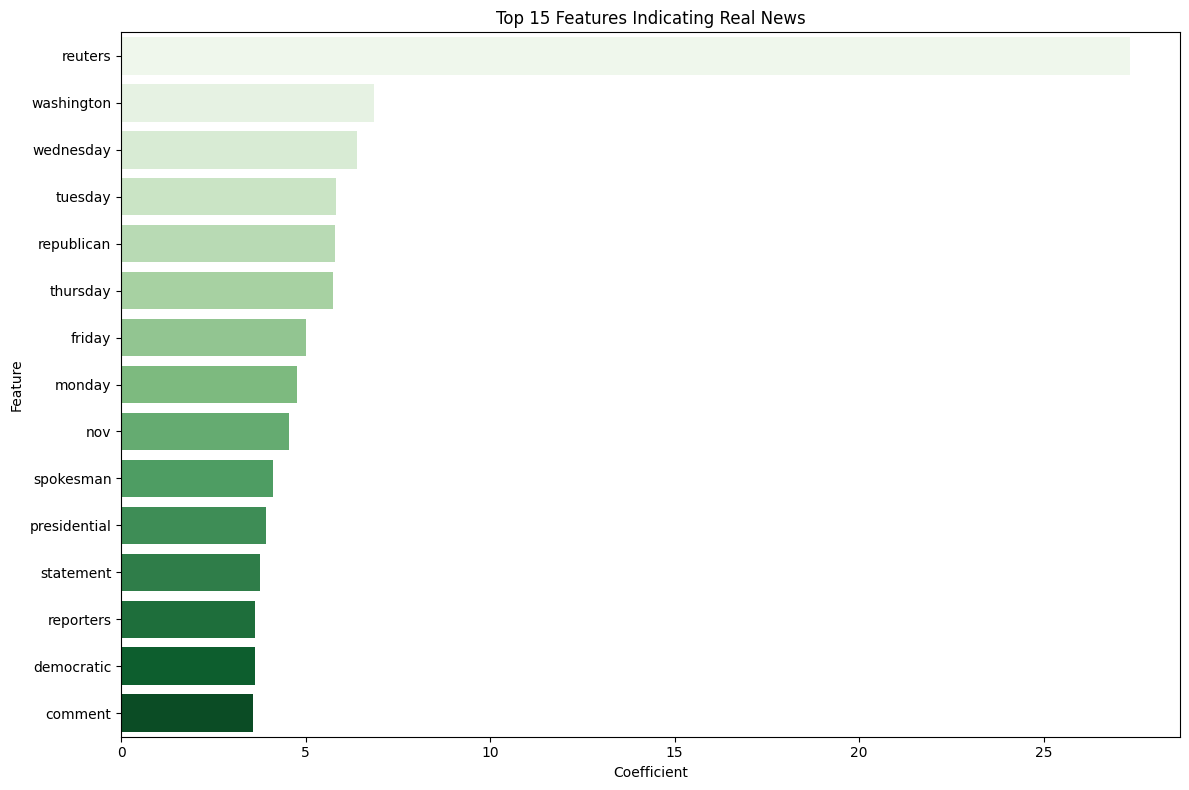

In [33]:
# Plot top features indicating real news (positive coefficients)
plt.figure(figsize=(12, 8))
top_real_features = coef_df[coef_df['Coefficient'] > 0].head(15)
sns.barplot(x='Coefficient', y='Feature', data=top_real_features, palette='Greens')
plt.title('Top 15 Features Indicating Real News')
plt.tight_layout()
plt.show()


In [34]:
def predict_news(text, model=model, vectorizer=vectorizer):
    """
    Predicts whether the input text is fake or real news.

    Parameters:
    - text: News text to classify
    - model: Trained classifier
    - vectorizer: Fitted TF-IDF vectorizer

    Returns:
    - Prediction result and probability
    """
    # Transform text using the same vectorizer
    text_tfidf = vectorizer.transform([text])

    # Make prediction
    prediction = model.predict(text_tfidf)[0]

    # Get probability
    probability = model.predict_proba(text_tfidf)[0]
    confidence = probability[prediction]

    if prediction == 0:
        return f"🔴 This news is likely *Fake* (Confidence: {confidence:.2f})"
    else:
        return f"🟢 This news is likely *Real* (Confidence: {confidence:.2f})"


In [35]:
print("\nExample Prediction:")
example_text = "BREAKING: Scientists discover aliens are controlling the world governments"
print(predict_news(example_text))


Example Prediction:
🔴 This news is likely *Fake* (Confidence: 0.98)


In [36]:
import pickle
import os

In [37]:
model_dir = '/content/drive/MyDrive/fake_news_model'
os.makedirs(model_dir, exist_ok=True)

In [38]:
with open(f'{model_dir}/fake_news_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{model_dir}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"\nModel and vectorizer saved to {model_dir}")


Model and vectorizer saved to /content/drive/MyDrive/fake_news_model


In [39]:
# NOW THE API INTEGRATION AND MODEL TESTING BEGINS

In [40]:
# Step 9: API Integration - Real-Time News API
import requests
import pandas as pd
import pickle

# Load the saved model and vectorizer
model_dir = '/content/drive/MyDrive/fake_news_model'

with open(f'{model_dir}/fake_news_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open(f'{model_dir}/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

print("Model and vectorizer loaded successfully.")

# Function to fetch news from Real Time News Data API
def fetch_real_time_news(topic="TECHNOLOGY", limit=20):
    url = "https://real-time-news-data.p.rapidapi.com/topic-news-by-section"

    params = {
        "topic": topic,
        "section": "CAQiSkNCQVNNUW9JTDIwdk1EZGpNWFlTQldWdUxVZENHZ0pKVENJT0NBUWFDZ29JTDIwdk1ETnliSFFxQ2hJSUwyMHZNRE55YkhRb0FBKi4IACoqCAoiJENCQVNGUW9JTDIwdk1EZGpNWFlTQldWdUxVZENHZ0pKVENnQVABUAE",
        "limit": str(limit),
        "country": "US",
        "lang": "en"
    }

    headers = {
        "x-rapidapi-host": "real-time-news-data.p.rapidapi.com",
        "x-rapidapi-key": "279787e5ebmshae780425efe1ad6p170c71jsna27942767b11"
    }

    print(f"Fetching {limit} {topic} news articles...")
    try:
        response = requests.get(url, headers=headers, params=params)
        response.raise_for_status()
        data = response.json()
        return data
    except requests.exceptions.RequestException as e:
        print(f"Error fetching news: {e}")
        return None

# Function to process the API response
def process_api_response(api_response):
    articles = []

    # Corrected: Access inside 'data' key
    if 'data' in api_response and api_response['data']:
        for article in api_response['data']:
            title = article.get('title', '')
            content = article.get('snippet', '')  # snippet is better than description here
            source = article.get('source_url', 'Unknown Source')  # fixed source extraction
            url = article.get('link', '')  # fixed URL extraction
            published_date = article.get('published_datetime_utc', '')

            articles.append({
                'title': title,
                'content': title + ' ' + content,
                'source': source,
                'url': url,
                'published_date': published_date
            })

        print(f"Processed {len(articles)} articles.")
    else:
        print("No news articles found in the API response.")

    return pd.DataFrame(articles)

# Fetch news articles
api_response = fetch_real_time_news(topic="TECHNOLOGY", limit=20)

if api_response:
    # Process the response
    news_df = process_api_response(api_response)

    # Save raw articles for later reference
    news_df.to_csv('/content/drive/MyDrive/api_news_articles.csv', index=False)
    print("Raw articles saved to Drive for reference.")
else:
    print("Failed to fetch news from API.")


Model and vectorizer loaded successfully.
Fetching 20 TECHNOLOGY news articles...
Processed 20 articles.
Raw articles saved to Drive for reference.


Loaded 20 articles from saved file.
Adding sentiment analysis...

===== NEWS CLASSIFICATION RESULTS =====
Total articles analyzed: 20
Fake news detected: 18 (90.0%)
Real news detected: 2 (10.0%)

----- DETAILED RESULTS -----

1. How the Internet Left 4chan Behind
   Source: https://www.newyorker.com
   Result: 🔴 Fake (Confidence: 0.91)
   Sentiment: 0.13 (Positive)
   URL: https://www.newyorker.com/culture/infinite-scroll/how-the-internet-left-4chan-behind

2. Orb, a new app by Ookla's ex-CEO, offers a broader picture of your internet connection
   Source: https://techcrunch.com
   Result: 🔴 Fake (Confidence: 0.50)
   Sentiment: 0.12 (Positive)
   URL: https://techcrunch.com/2025/04/30/former-ookla-ceos-new-app-aims-to-measure-internet-reliablity-along-with-speed/

3. Did the Internet Die in 2016? There's an Online Community That Thinks So
   Source: https://www.cnet.com
   Result: 🔴 Fake (Confidence: 0.95)
   Sentiment: -0.05 (Negative)
   URL: https://www.cnet.com/home/internet/what-

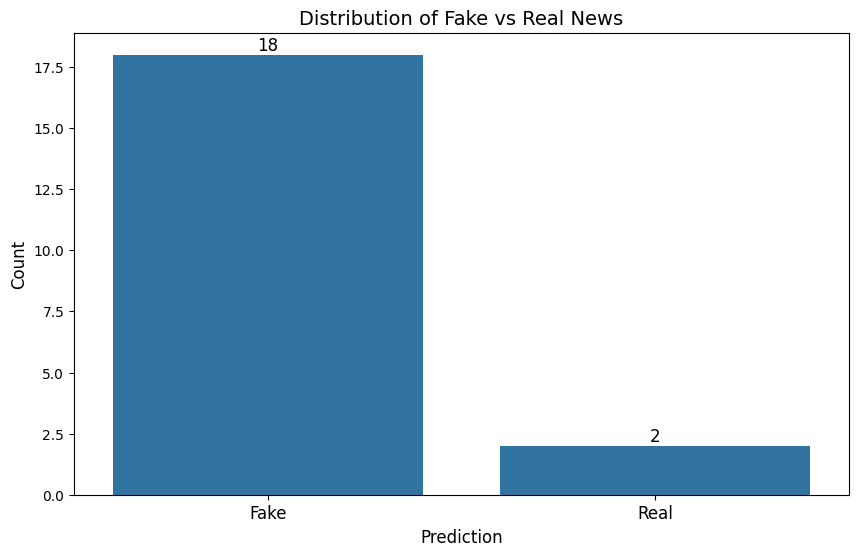

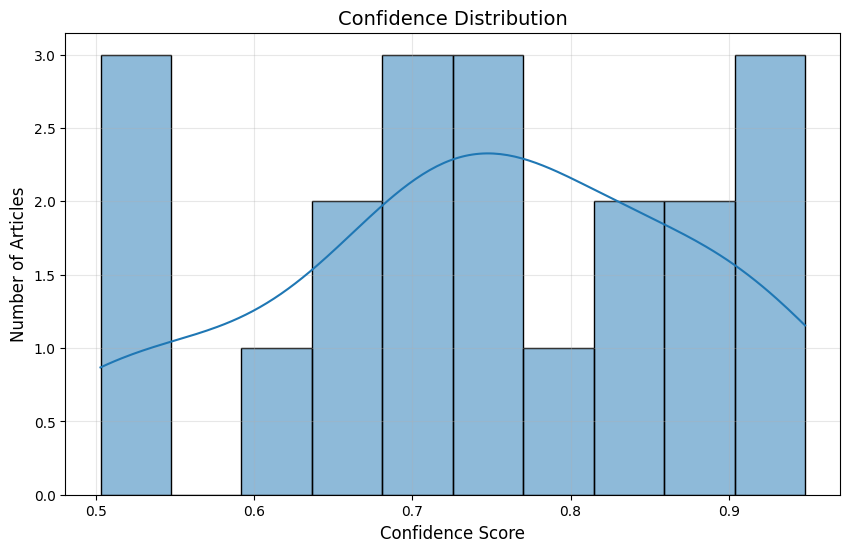

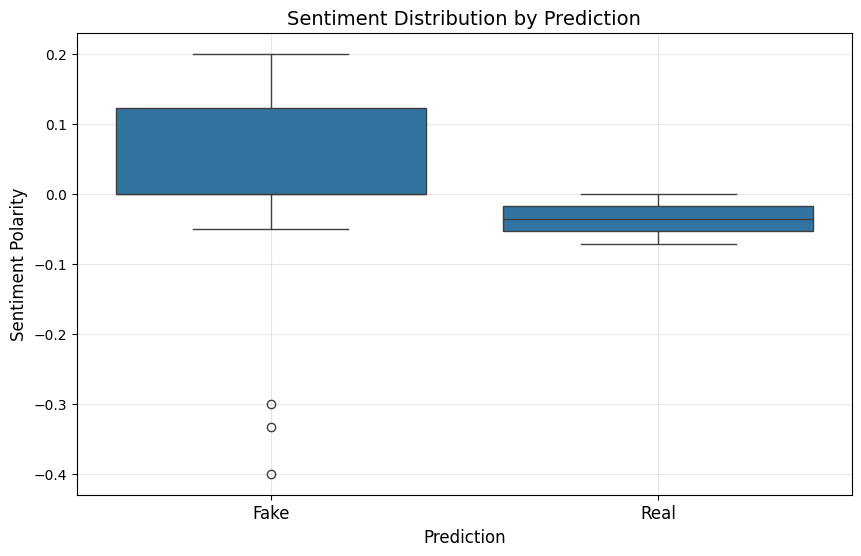

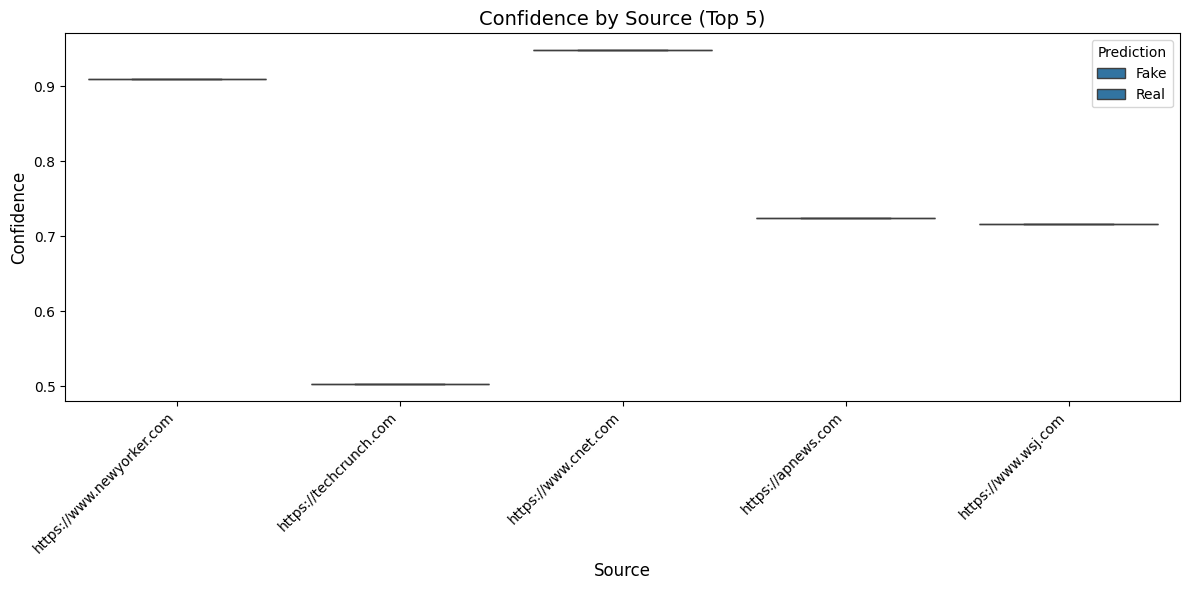


Results saved to '/content/drive/MyDrive/news_analysis_results.csv'

===== CUSTOM NEWS TESTING =====
Enter a news article to classify (press Enter on an empty title to exit):

Title: Americans lost record $16.6 billion to internet scams last year
Content: Adults over 60 remain the most vulnerable group, reporting nearly $5 billion in losses to various internet scams

--- RESULT ---
🔴 This news is likely FAKE (Confidence: 0.57)
Sentiment: 0.02 (Positive)


In [ ]:
# Step 10: News Testing and Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Make sure news_df is available
try:
    # If you're running this in a separate session, load the saved articles
    news_df = pd.read_csv('/content/drive/MyDrive/api_news_articles.csv')
    print(f"Loaded {len(news_df)} articles from saved file.")
except:
    # If running right after the previous block, news_df should already be in memory
    if 'news_df' not in globals():
        print("Error: No news articles found. Run the API integration block first.")
        exit()

# Function to predict fake/real news for a batch of articles
def predict_news_batch(df, model, vectorizer):
    """
    Predicts whether each news article in the DataFrame is fake or real.

    Parameters:
    - df: DataFrame with 'content' column containing news text
    - model: Trained classifier
    - vectorizer: Fitted TF-IDF vectorizer

    Returns:
    - DataFrame with predictions and confidence scores
    """
    if df.empty:
        print("No articles to analyze.")
        return df

    # Transform text using the vectorizer
    X_tfidf = vectorizer.transform(df['content'])

    # Make predictions
    predictions = model.predict(X_tfidf)

    # Get probabilities
    probabilities = model.predict_proba(X_tfidf)

    # Add predictions to the DataFrame
    df['prediction'] = predictions
    df['confidence'] = [prob[pred] for pred, prob in zip(predictions, probabilities)]
    df['result'] = df.apply(
        lambda row: f"🔴 Fake (Confidence: {row['confidence']:.2f})" if row['prediction'] == 0
                   else f"🟢 Real (Confidence: {row['confidence']:.2f})",
        axis=1
    )

    # Add sentiment analysis
    print("Adding sentiment analysis...")
    df['sentiment'] = df['content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    return df

# Helper function for sentiment categorization
def sentiment_category(score):
    if score > 0.2:
        return "Very Positive"
    elif score > 0:
        return "Positive"
    elif score > -0.2:
        return "Negative"
    else:
        return "Very Negative"

# Analyze the news articles
results_df = predict_news_batch(news_df, model, vectorizer)

# Display results
print("\n===== NEWS CLASSIFICATION RESULTS =====")
print(f"Total articles analyzed: {len(results_df)}")
fake_count = len(results_df[results_df['prediction'] == 0])
real_count = len(results_df[results_df['prediction'] == 1])
print(f"Fake news detected: {fake_count} ({fake_count/len(results_df)*100:.1f}%)")
print(f"Real news detected: {real_count} ({real_count/len(results_df)*100:.1f}%)")

# Display detailed results
print("\n----- DETAILED RESULTS -----")
for i, row in results_df.iterrows():
    print(f"\n{i+1}. {row['title']}")
    print(f"   Source: {row['source']}")
    print(f"   Result: {row['result']}")
    print(f"   Sentiment: {row['sentiment']:.2f} ({sentiment_category(row['sentiment'])})")
    print(f"   URL: {row['url']}")

# Visualizations of the results
print("\n----- GENERATING VISUALIZATIONS -----")

# 1. Distribution of fake vs real news
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='prediction', data=results_df)
plt.title('Distribution of Fake vs Real News', fontsize=14)
plt.xticks([0, 1], ['Fake', 'Real'], fontsize=12)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

# 2. Confidence distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_df['confidence'], bins=10, kde=True)
plt.title('Confidence Distribution', fontsize=14)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Sentiment distribution by prediction
plt.figure(figsize=(10, 6))
sns.boxplot(x='prediction', y='sentiment', data=results_df)
plt.title('Sentiment Distribution by Prediction', fontsize=14)
plt.xticks([0, 1], ['Fake', 'Real'], fontsize=12)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 4. Source analysis (if we have enough unique sources)
if results_df['source'].nunique() > 1:
    top_sources = results_df['source'].value_counts().head(5).index
    source_df = results_df[results_df['source'].isin(top_sources)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='source', y='confidence', hue='prediction', data=source_df)
    plt.title('Confidence by Source (Top 5)', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xlabel('Source', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.legend(title='Prediction', labels=['Fake', 'Real'])
    plt.tight_layout()
    plt.show()

# Save the results
results_df.to_csv('/content/drive/MyDrive/news_analysis_results.csv', index=False)
print("\nResults saved to '/content/drive/MyDrive/news_analysis_results.csv'")

# Interactive testing function
def test_custom_news():
    """
    Let the user input a custom news article for testing
    """
    print("\n===== CUSTOM NEWS TESTING =====")
    print("Enter a news article to classify (press Enter on an empty title to exit):")

    while True:
        title = input("\nTitle: ")
        if not title:
            break

        content = input("Content: ")

        # Combine title and content
        full_text = title + " " + content

        # Transform text using the vectorizer
        text_tfidf = vectorizer.transform([full_text])

        # Make prediction
        prediction = model.predict(text_tfidf)[0]

        # Get probability
        probability = model.predict_proba(text_tfidf)[0]
        confidence = probability[prediction]

        # Get sentiment
        sentiment = TextBlob(full_text).sentiment.polarity

        # Display result
        print("\n--- RESULT ---")
        if prediction == 0:
            print(f"🔴 This news is likely FAKE (Confidence: {confidence:.2f})")
        else:
            print(f"🟢 This news is likely REAL (Confidence: {confidence:.2f})")

        print(f"Sentiment: {sentiment:.2f} ({sentiment_category(sentiment)})")

        # Ask if they want to test another
        another = input("\nTest another article? (y/n): ")
        if another.lower() != 'y':
            break

# Run the interactive testing function
test_custom_news()